# Classificação de Estágios CVM com CNN (Transfer Learning)
**Dataset:** 'Aariz Cephalometric Dataset  
**Tarefa:** Classificação multiclasse — CVM-S1 a CVM-S6  
**Abordagem:** ResNet-50 com fine-tuning  

---
## Estrutura esperada do dataset
```
Aariz/
├── train/
│   ├── Cephalograms/          ← imagens PNG
│   └── Annotations/
│       └── CVM Stages/        ← arquivos .json com label
├── valid/
│   ├── Cephalograms/
│   └── Annotations/
│       └── CVM Stages/
└── test/
    ├── Cephalograms/
    └── Annotations/
        └── CVM Stages/
```

## 0. Instalação de dependências

In [1]:
# Execute esta célula apenas uma vez
!pip install torch torchvision tqdm scikit-learn matplotlib seaborn pandas Pillow opencv-python --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports e configuração geral

In [5]:
import os, json, random, zipfile
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# ── Reprodutibilidade ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Dispositivo ───────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {DEVICE}')

# ── Extração do dataset ───────────────────────────────────────────────────────
# Coloque o Aariz.zip na mesma pasta do notebook e ajuste o caminho abaixo
ZIP_PATH    = Path("Aariz.zip")          # ← caminho para o ZIP baixado
EXTRACT_DIR = Path("Aariz_extracted")    # ← onde vai extrair

if not EXTRACT_DIR.exists():
    print("Extraindo...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Extração concluída.")
else:
    print("Já extraído, pulando.")

# ── Detecta automaticamente onde ficaram os splits ───────────────────────────
DATASET_ROOT = None
for root, dirs, _ in os.walk(EXTRACT_DIR):
    if {'train', 'valid', 'test'}.issubset(set(dirs)):
        DATASET_ROOT = Path(root)
        break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Não encontrei train/valid/test dentro do ZIP.\n"
        "Verifique a estrutura extraída em: " + str(EXTRACT_DIR)
    )

print(f'DATASET_ROOT detectado: {DATASET_ROOT}')

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_CLASSES = 6
EPOCHS      = 30
LR          = 1e-4
LR_STEP     = 10
LR_GAMMA    = 0.5

CLASS_NAMES = ['CVM-S1', 'CVM-S2', 'CVM-S3', 'CVM-S4', 'CVM-S5', 'CVM-S6']
print('Configuração concluída.')

Dispositivo em uso: cpu
Extraindo...
Extração concluída.
DATASET_ROOT detectado: Aariz_extracted\Aariz
Configuração concluída.


## 2. Leitura e indexação dos dados
Lê os `.json` de CVM Stage e cruza com as imagens correspondentes.

In [7]:
# ── Cole e rode esta célula ANTES do load_split ───────────────────────────────

print("=== Estrutura de pastas ===")
for root, dirs, files in os.walk(DATASET_ROOT):
    depth = root.replace(str(DATASET_ROOT), '').count(os.sep)
    if depth > 4:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        subindent = '  ' * (depth + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")
        if len(files) > 3:
            print(f"{subindent}... (+{len(files)-3})")

print("\n=== Exemplo de JSON de CVM ===")
# Pega o primeiro JSON que encontrar dentro de qualquer pasta
for root, dirs, files in os.walk(DATASET_ROOT):
    json_files = [f for f in files if f.endswith('.json')]
    if json_files and ('cvm' in root.lower() or 'stage' in root.lower() or 'Stage' in root):
        sample = Path(root) / json_files[0]
        print(f"Arquivo: {sample}")
        with open(sample) as f:
            print(json.dumps(json.load(f), indent=2))
        break

print("\n=== Extensões de imagem encontradas ===")
exts = set()
for root, dirs, files in os.walk(DATASET_ROOT):
    for f in files:
        exts.add(Path(f).suffix.lower())
print(exts)

=== Estrutura de pastas ===
Aariz/
  cephalogram_machine_mappings.csv
  Readme.txt
  test/
    Annotations/
      Cephalometric Landmarks/
        Junior Orthodontists/
          cks2ip8fp29yl0yuf6ry9266i.json
          cks2ip8fq29zp0yuf7cxd3bz2.json
          cks2ip8fq29zz0yuf15jsfhlu.json
          ... (+147)
        Senior Orthodontists/
          cks2ip8fp29yl0yuf6ry9266i.json
          cks2ip8fq29zp0yuf7cxd3bz2.json
          cks2ip8fq29zz0yuf15jsfhlu.json
          ... (+147)
      CVM Stages/
        cks2ip8fp29yl0yuf6ry9266i.json
        cks2ip8fq29zp0yuf7cxd3bz2.json
        cks2ip8fq29zz0yuf15jsfhlu.json
        ... (+147)
    Cephalograms/
      cks2ip8fp29yl0yuf6ry9266i.png
      cks2ip8fq29zp0yuf7cxd3bz2.png
      cks2ip8fq29zz0yuf15jsfhlu.png
      ... (+147)
  train/
    Annotations/
      Cephalometric Landmarks/
        Junior Orthodontists/
          cks2ip8fq29yq0yufc4scftj8.json
          cks2ip8fq29z00yufgnfla2tf.json
          cks2ip8fq29za0yuf0tqu1qjs.json
      

In [8]:
def load_split(split: str) -> pd.DataFrame:
    img_dir = DATASET_ROOT / split / 'Cephalograms'
    ann_dir = DATASET_ROOT / split / 'Annotations' / 'CVM Stages'

    records = []
    for json_path in sorted(ann_dir.glob('*.json')):
        with open(json_path) as f:
            data = json.load(f)

        # cvm_stage é um objeto — extrai o campo 'title'
        cvm_obj = data.get('cvm_stage', {})
        stage   = cvm_obj.get('title', '').strip()

        if not stage:
            continue  # JSON sem stage válido, pula

        # Localiza imagem com mesmo stem (tenta png, jpg, bmp, jpeg)
        img_path = None
        for ext in ['.png', '.jpg', '.bmp', '.jpeg']:
            candidate = img_dir / (json_path.stem + ext)
            if candidate.exists():
                img_path = candidate
                break

        if img_path and stage in CLASS_NAMES:
            records.append({
                'image_path': str(img_path),
                'label':      stage,
                'label_idx':  CLASS_NAMES.index(stage)
            })

    df = pd.DataFrame(records)
    print(f'[{split}] {len(df)} imagens carregadas.')
    return df


df_train = load_split('train')
df_valid = load_split('valid')
df_test  = load_split('test')

print('\nDistribuição de classes — treino:')
print(df_train['label'].value_counts().sort_index())

[train] 700 imagens carregadas.
[valid] 150 imagens carregadas.
[test] 150 imagens carregadas.

Distribuição de classes — treino:
label
CVM-S1     18
CVM-S2     38
CVM-S3     37
CVM-S4    185
CVM-S5    311
CVM-S6    111
Name: count, dtype: int64


## 3. Análise exploratória — distribuição de classes

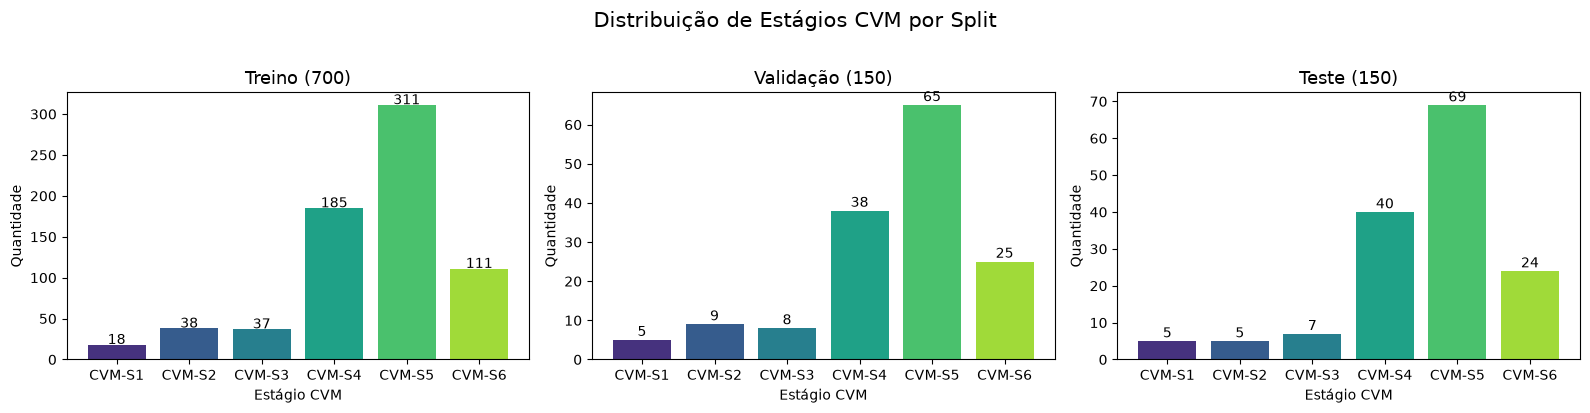


Pesos por classe (class_weight):
  CVM-S1: 2.6345
  CVM-S2: 1.2479
  CVM-S3: 1.2816
  CVM-S4: 0.2563
  CVM-S5: 0.1525
  CVM-S6: 0.4272


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = sns.color_palette('viridis', NUM_CLASSES)

for ax, (df, title) in zip(axes, [
    (df_train, 'Treino (700)'),
    (df_valid, 'Validação (150)'),
    (df_test,  'Teste (150)')
]):
    counts = df['label'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    ax.bar(CLASS_NAMES, counts.values, color=colors)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Estágio CVM')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Distribuição de Estágios CVM por Split', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Peso por classe para compensar desbalanceamento
counts_train = df_train['label'].value_counts().reindex(CLASS_NAMES, fill_value=1)
class_weights = torch.tensor(
    [1.0 / counts_train[c] for c in CLASS_NAMES], dtype=torch.float
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

print('\nPesos por classe (class_weight):')
for name, w in zip(CLASS_NAMES, class_weights.cpu()):
    print(f'  {name}: {w:.4f}')

## 4. Dataset PyTorch com pré-processamento e augmentation

In [12]:
def apply_clahe(img_np: np.ndarray) -> np.ndarray:
    """
    CLAHE — melhora contraste local de radiografias.
    Entrada: imagem RGB uint8. Saída: RGB uint8.
    """
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


class CVMDataset(Dataset):
    """
    Dataset para classificação CVM.
    Aplica CLAHE antes das transforms do torchvision.
    """
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label_idx'])

        # Leitura e conversão para RGB
        img_bgr = cv2.imread(row['image_path'])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # CLAHE no espaço LAB
        img_rgb = apply_clahe(img_rgb)

        # Converte para PIL para usar transforms torchvision
        from PIL import Image
        img_pil = Image.fromarray(img_rgb)

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, label


# ── Estatísticas ImageNet (usadas no fine-tuning) ─────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transforms ────────────────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = CVMDataset(df_train, transform=transform_train)
valid_ds  = CVMDataset(df_valid, transform=transform_eval)
test_ds   = CVMDataset(df_test,  transform=transform_eval)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batches — treino: {len(train_loader)} | validação: {len(valid_loader)} | teste: {len(test_loader)}')

Batches — treino: 44 | validação: 10 | teste: 10


## 5. Visualização de amostras pré-processadas

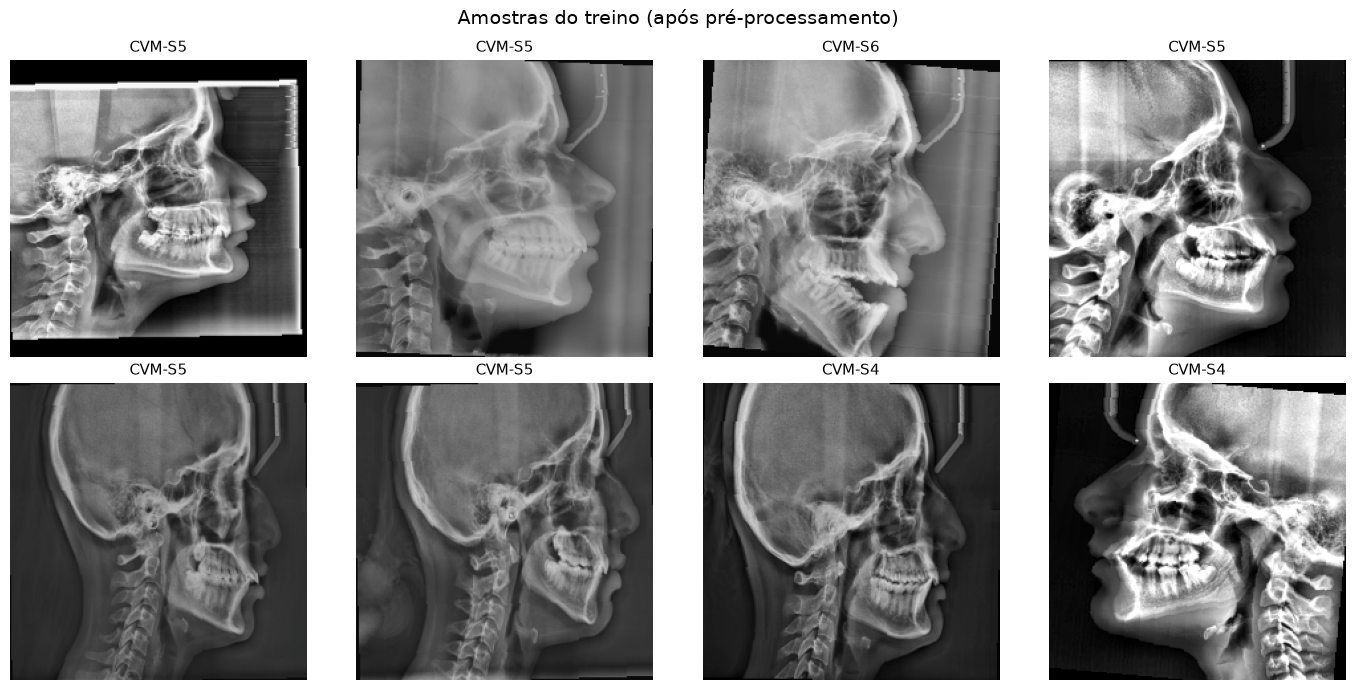

In [13]:
def denormalize(tensor):
    """Reverte normalização ImageNet para visualização."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.flat):
    if i >= len(imgs):
        ax.axis('off')
        continue
    img_show = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=11)
    ax.axis('off')

plt.suptitle('Amostras do treino (após pré-processamento)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Arquitetura — ResNet-50 com fine-tuning

In [14]:
def build_model(num_classes: int = NUM_CLASSES, freeze_backbone: bool = False) -> nn.Module:
    """
    ResNet-50 pré-treinada com cabeça de classificação substituída.
    
    Arquitetura da cabeça:
        Global Average Pooling (já na ResNet)
        → Linear(2048, 512) + ReLU + Dropout(0.5)
        → Linear(512, num_classes)
    
    freeze_backbone=True: treina somente a cabeça (útil nas primeiras épocas).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Substitui a camada final
    in_features = model.fc.in_features          # 2048 na ResNet-50
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    )

    return model.to(DEVICE)


model = build_model(freeze_backbone=False)

# Resumo do modelo
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros totais:    {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}')
print(f'Cabeça final:\n{model.fc}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Anna/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:55<00:00, 1.85MB/s]


Parâmetros totais:    24,560,198
Parâmetros treináveis: 24,560,198
Cabeça final:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=6, bias=True)
)


## 7. Configuração do treinamento

In [15]:
# Loss com pesos para compensar desbalanceamento
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Otimizador com weight decay (regularização L2)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Scheduler: reduz LR a cada LR_STEP épocas
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

print('Critério:', criterion)
print('Otimizador:', optimizer)
print('Scheduler: StepLR — step:', LR_STEP, '| gamma:', LR_GAMMA)

Critério: CrossEntropyLoss()
Otimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: StepLR — step: 10 | gamma: 0.5


## 8. Loop de treinamento

In [16]:
def run_epoch(model, loader, criterion, optimizer=None, phase='train'):
    """
    Executa uma época completa.
    Se optimizer=None, roda em modo de avaliação (sem gradientes).
    Retorna (loss_média, acurácia).
    """
    is_training = (phase == 'train')
    model.train() if is_training else model.eval()

    running_loss = 0.0
    correct      = 0
    total        = 0

    ctx = torch.enable_grad() if is_training else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, desc=phase, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss    = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

    return running_loss / total, correct / total


# ── Histórico ─────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_model_path = 'best_cvm_model.pth'

print(f'Iniciando treinamento por {EPOCHS} épocas...\n')

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, phase='train')
    val_loss,   val_acc   = run_epoch(model, valid_loader, criterion, phase='val')
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Salva o melhor modelo (critério: acurácia na validação)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        flag = '  ← melhor'
    else:
        flag = ''

    lr_now = scheduler.get_last_lr()[0]
    print(f'Época {epoch:02d}/{EPOCHS} | '
          f'Loss treino: {train_loss:.4f} | Acc treino: {train_acc:.4f} | '
          f'Loss val: {val_loss:.4f} | Acc val: {val_acc:.4f} | '
          f'LR: {lr_now:.2e}{flag}')

print(f'\nMelhor acurácia de validação: {best_val_acc:.4f}')

Iniciando treinamento por 30 épocas...



Época 01/30 | Loss treino: 1.8236 | Acc treino: 0.2800 | Loss val: 1.7644 | Acc val: 0.2267 | LR: 1.00e-04  ← melhor


Época 02/30 | Loss treino: 1.7161 | Acc treino: 0.2900 | Loss val: 1.6868 | Acc val: 0.3133 | LR: 1.00e-04  ← melhor


Época 03/30 | Loss treino: 1.5182 | Acc treino: 0.3386 | Loss val: 1.7799 | Acc val: 0.4133 | LR: 1.00e-04  ← melhor


Época 04/30 | Loss treino: 1.4153 | Acc treino: 0.3371 | Loss val: 1.7031 | Acc val: 0.3600 | LR: 1.00e-04


...

Época 26/30 | Loss treino: 0.2258 | Acc treino: 0.8686 | Loss val: 2.1727 | Acc val: 0.5333 | LR: 2.50e-05


Época 27/30 | Loss treino: 0.1925 | Acc treino: 0.8786 | Loss val: 2.2864 | Acc val: 0.5000 | LR: 2.50e-05


Época 28/30 | Loss treino: 0.2275 | Acc treino: 0.9000 | Loss val: 2.2451 | Acc val: 0.4933 | LR: 2.50e-05


Época 29/30 | Loss treino: 0.1879 | Acc treino: 0.9043 | Loss val: 2.3735 | Acc val: 0.4667 | LR: 2.50e-05


Época 30/30 | Loss treino: 0.1962 | Acc treino: 0.9100 | Loss val: 2.5038 | Acc val: 0.5067 | LR: 1.25e-05

Melhor acurácia de validação: 0.5333


## 9. Curvas de aprendizado

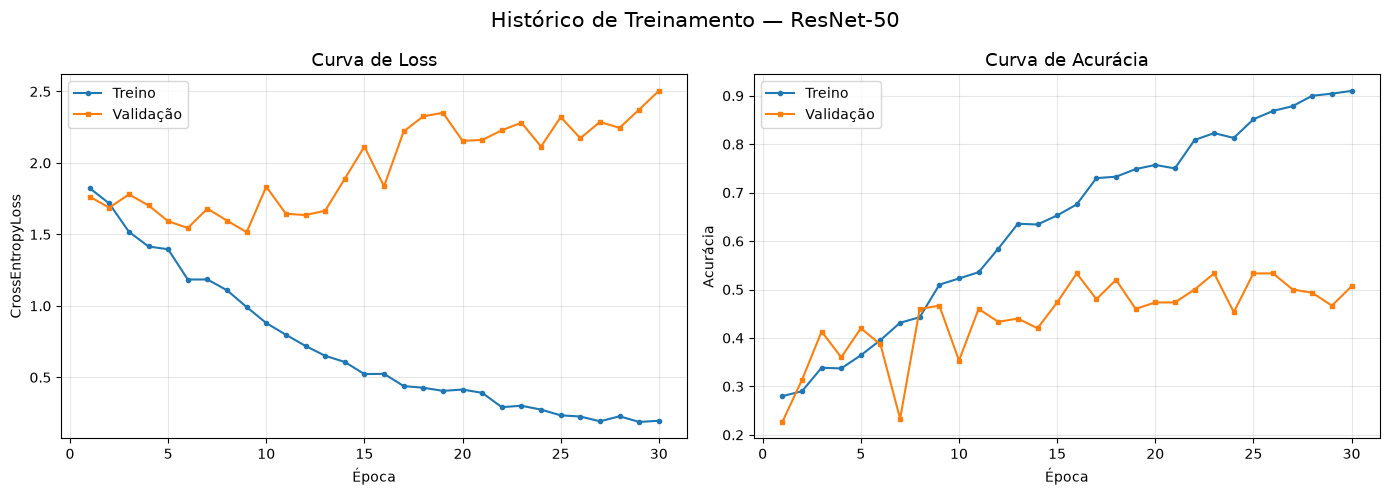

Gráfico salvo em curvas_treinamento.png


In [17]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Treino', marker='o', markersize=3)
axes[0].plot(epochs_range, history['val_loss'],   label='Validação', marker='s', markersize=3)
axes[0].set_title('Curva de Loss', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('CrossEntropyLoss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Acurácia
axes[1].plot(epochs_range, history['train_acc'], label='Treino', marker='o', markersize=3)
axes[1].plot(epochs_range, history['val_acc'],   label='Validação', marker='s', markersize=3)
axes[1].set_title('Curva de Acurácia', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Histórico de Treinamento — ResNet-50', fontsize=15)
plt.tight_layout()
plt.savefig('curvas_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo em curvas_treinamento.png')

## 10. Avaliação no conjunto de teste

In [18]:
def evaluate_test(model, loader):
    """
    Coleta predições e probabilidades para o conjunto de teste.
    Retorna (y_true, y_pred, y_prob).
    """
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Testando'):
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = probs.argmax(axis=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


# Carrega o melhor modelo
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
y_true, y_pred, y_prob = evaluate_test(model, test_loader)

# ── Métricas gerais ───────────────────────────────────────────────────────────
acc_test = (y_true == y_pred).mean()
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

# AUC-ROC one-vs-rest
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_macro = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

print('=' * 55)
print(f'  MÉTRICAS NO CONJUNTO DE TESTE')
print('=' * 55)
print(f'  Acurácia          : {acc_test:.4f} ({acc_test*100:.2f}%)')
print(f'  F1-Score (macro)  : {f1_macro:.4f}')
print(f'  F1-Score (weighted): {f1_weighted:.4f}')
print(f'  AUC-ROC (macro OvR): {auc_macro:.4f}')
print('=' * 55)

print('\nRelatório por classe:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Testando: 100%|██████████| 10/10 [00:34<00:00,  3.41s/it]


  MÉTRICAS NO CONJUNTO DE TESTE
  Acurácia          : 0.5067 (50.67%)
  F1-Score (macro)  : 0.4073
  F1-Score (weighted): 0.5102
  AUC-ROC (macro OvR): 0.7952

Relatório por classe:
              precision    recall  f1-score   support

      CVM-S1       0.50      0.40      0.44         5
      CVM-S2       0.22      0.40      0.29         5
      CVM-S3       0.50      0.14      0.22         7
      CVM-S4       0.53      0.47      0.50        40
      CVM-S5       0.63      0.59      0.61        69
      CVM-S6       0.32      0.46      0.38        24

    accuracy                           0.51       150
   macro avg       0.45      0.41      0.41       150
weighted avg       0.53      0.51      0.51       150



## 11. Matriz de confusão

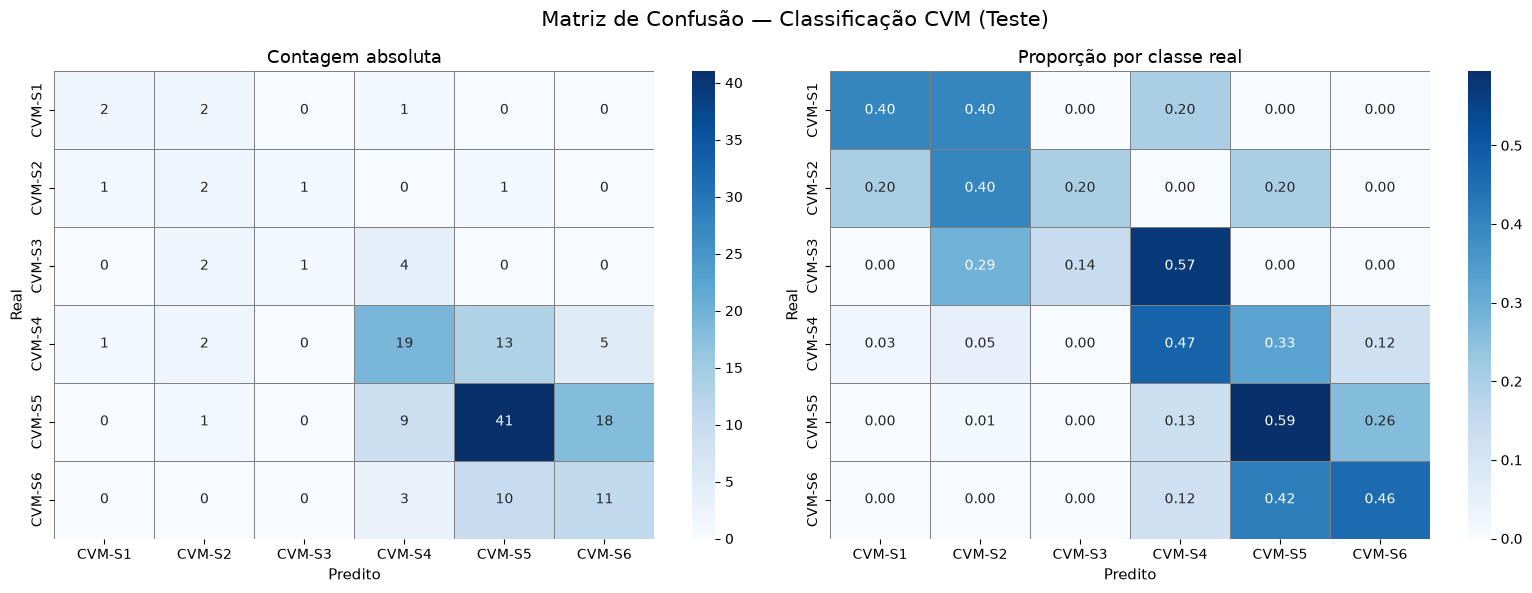

Salvo em matriz_confusao.png


In [19]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por linha

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Contagem absoluta'),
    (axes[1], cm_norm, '.2f',  'Proporção por classe real')
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5, linecolor='grey'
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predito', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)

plt.suptitle('Matriz de Confusão — Classificação CVM (Teste)', fontsize=15)
plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em matriz_confusao.png')

## 12. Curvas ROC por classe

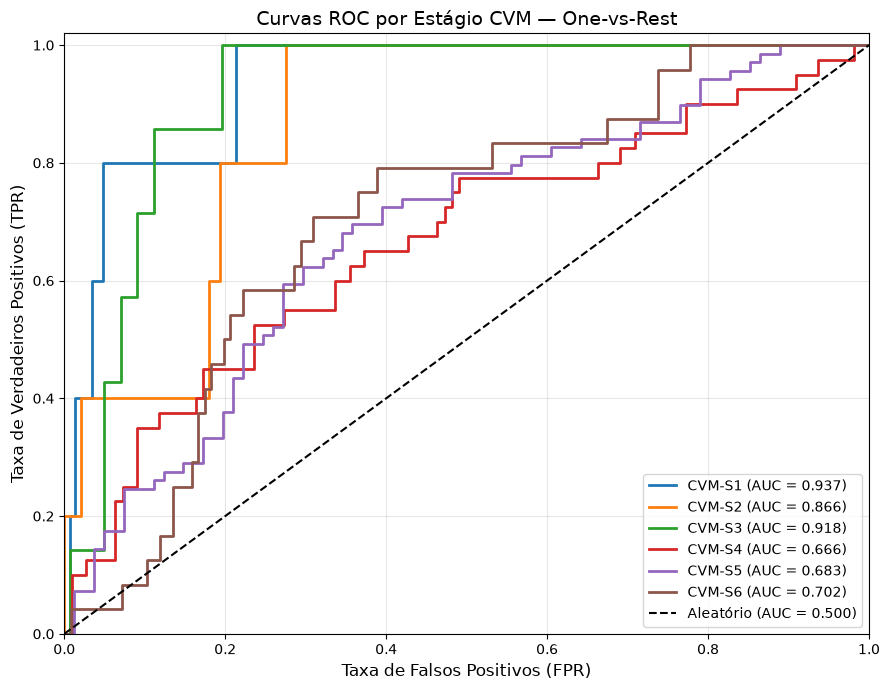

Salvo em curvas_roc.png


In [20]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = sns.color_palette('tab10', NUM_CLASSES)

for i, (cname, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cname} (AUC = {roc_auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC por Estágio CVM — One-vs-Rest', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em curvas_roc.png')

## 13. Visualização de predições com imagens reais

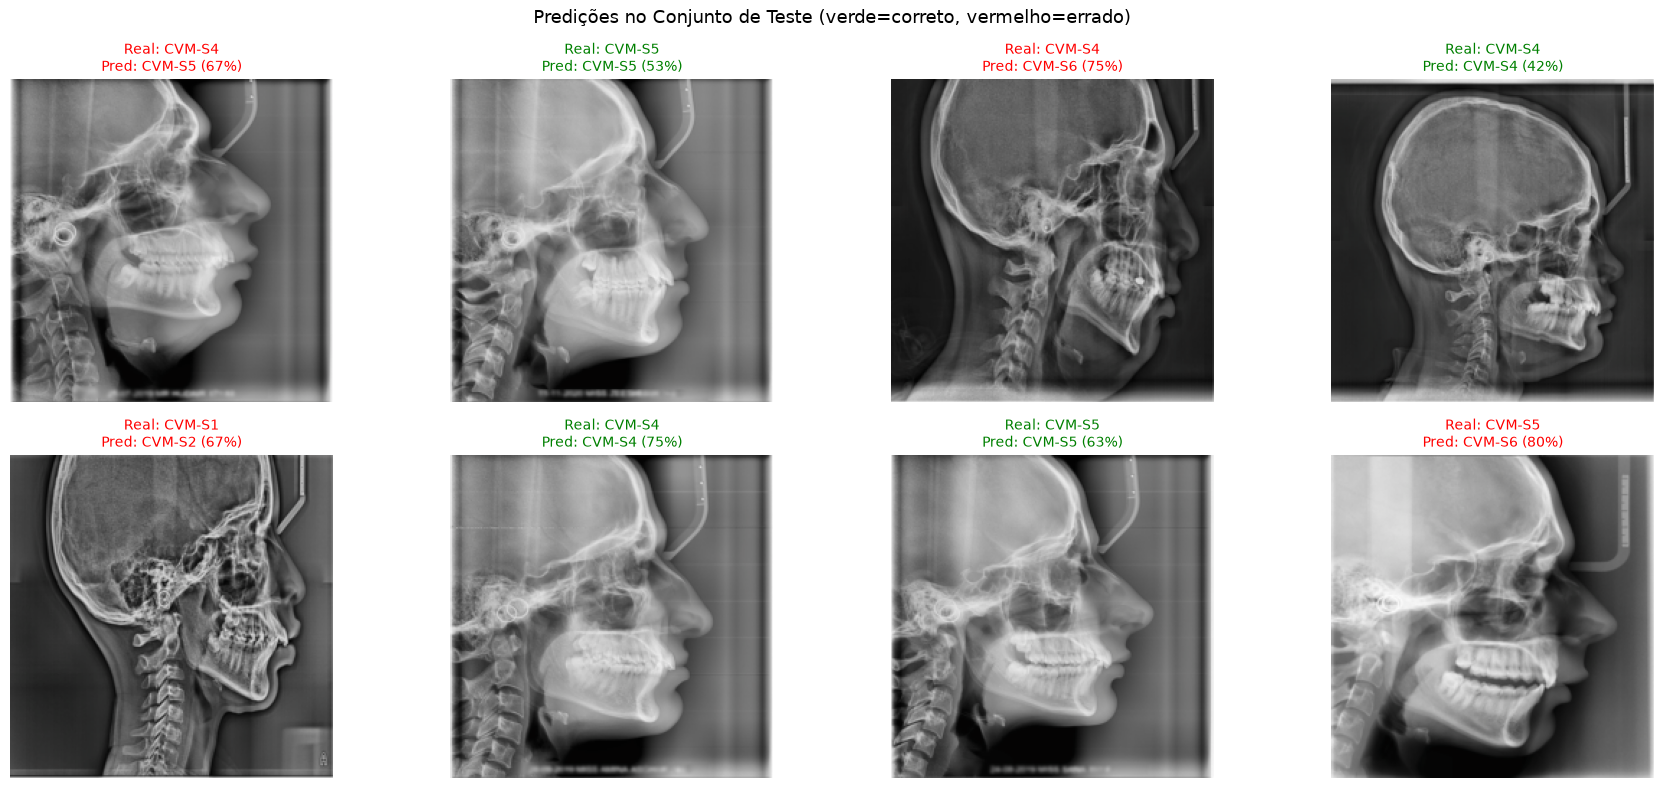

In [21]:
def show_predictions(model, dataset, num_samples=8):
    """
    Mostra imagens do conjunto de teste com predição e rótulo real.
    Verde = correto | Vermelho = incorreto.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(2, num_samples // 2, figsize=(18, 8))

    for ax, idx in zip(axes.flat, indices):
        img_tensor, true_label = dataset[idx]
        with torch.no_grad():
            out   = model(img_tensor.unsqueeze(0).to(DEVICE))
            pred  = out.argmax(dim=1).item()
            conf  = torch.softmax(out, dim=1)[0, pred].item()

        img_show = denormalize(img_tensor).permute(1, 2, 0).numpy()
        color    = 'green' if pred == true_label else 'red'

        ax.imshow(img_show, cmap='gray')
        ax.set_title(
            f'Real: {CLASS_NAMES[true_label]}\n'
            f'Pred: {CLASS_NAMES[pred]} ({conf:.0%})',
            color=color, fontsize=10
        )
        ax.axis('off')

    plt.suptitle('Predições no Conjunto de Teste (verde=correto, vermelho=errado)', fontsize=13)
    plt.tight_layout()
    plt.savefig('predicoes_teste.png', dpi=150, bbox_inches='tight')
    plt.show()


show_predictions(model, test_ds)

## 14. Salva resultados em CSV para o artigo

In [22]:
from sklearn.metrics import precision_score, recall_score

results = []
for i, cname in enumerate(CLASS_NAMES):
    mask = y_true == i
    results.append({
        'Classe':    cname,
        'N_real':    int(mask.sum()),
        'N_pred':    int((y_pred == i).sum()),
        'Precision': precision_score(y_true, y_pred, labels=[i], average='macro', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, labels=[i], average='macro', zero_division=0),
        'F1':        f1_score(y_true, y_pred, labels=[i], average='macro', zero_division=0),
    })

df_results = pd.DataFrame(results)

# Linha de resumo global
summary = pd.DataFrame([{
    'Classe':    'GERAL',
    'N_real':    len(y_true),
    'N_pred':    len(y_pred),
    'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
    'F1':        f1_macro,
}])

df_final = pd.concat([df_results, summary], ignore_index=True)
df_final = df_final.round(4)
df_final.to_csv('resultados_cvm.csv', index=False)

print('Resultados salvos em resultados_cvm.csv')
print(df_final.to_string(index=False))

Resultados salvos em resultados_cvm.csv
Classe  N_real  N_pred  Precision  Recall     F1
CVM-S1       5       4     0.5000  0.4000 0.4444
CVM-S2       5       9     0.2222  0.4000 0.2857
CVM-S3       7       2     0.5000  0.1429 0.2222
CVM-S4      40      36     0.5278  0.4750 0.5000
CVM-S5      69      65     0.6308  0.5942 0.6119
CVM-S6      24      34     0.3235  0.4583 0.3793
 GERAL     150     150     0.4507  0.4117 0.4073


## 15. Resumo final para o artigo

In [23]:
print('=' * 60)
print('  RESUMO PARA O ARTIGO')
print('=' * 60)
print(f'  Modelo              : ResNet-50 (fine-tuning, ImageNet)')
print(f'  Dataset             : Aariz (1000 LCRs, 7 dispositivos)')
print(f'  Split               : 700 / 150 / 150')
print(f'  Épocas treinadas    : {EPOCHS}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Learning rate (ini) : {LR}')
print(f'  Pré-processamento   : CLAHE + Normalização ImageNet')
print(f'  Augmentation        : Flip, Rotação ±5°, ColorJitter')
print(f'  Desbalanceamento    : CrossEntropyLoss com class_weight')
print('-' * 60)
print(f'  Acurácia (teste)    : {acc_test:.4f}')
print(f'  F1 macro (teste)    : {f1_macro:.4f}')
print(f'  F1 weighted (teste) : {f1_weighted:.4f}')
print(f'  AUC-ROC macro OvR   : {auc_macro:.4f}')
print('=' * 60)
print('Arquivos gerados:')
for f in ['best_cvm_model.pth', 'curvas_treinamento.png',
          'matriz_confusao.png', 'curvas_roc.png',
          'predicoes_teste.png', 'resultados_cvm.csv']:
    print(f'  • {f}')

  RESUMO PARA O ARTIGO
  Modelo              : ResNet-50 (fine-tuning, ImageNet)
  Dataset             : Aariz (1000 LCRs, 7 dispositivos)
  Split               : 700 / 150 / 150
  Épocas treinadas    : 30
  Batch size          : 16
  Learning rate (ini) : 0.0001
  Pré-processamento   : CLAHE + Normalização ImageNet
  Augmentation        : Flip, Rotação ±5°, ColorJitter
  Desbalanceamento    : CrossEntropyLoss com class_weight
------------------------------------------------------------
  Acurácia (teste)    : 0.5067
  F1 macro (teste)    : 0.4073
  F1 weighted (teste) : 0.5102
  AUC-ROC macro OvR   : 0.7952
Arquivos gerados:
  • best_cvm_model.pth
  • curvas_treinamento.png
  • matriz_confusao.png
  • curvas_roc.png
  • predicoes_teste.png
  • resultados_cvm.csv
